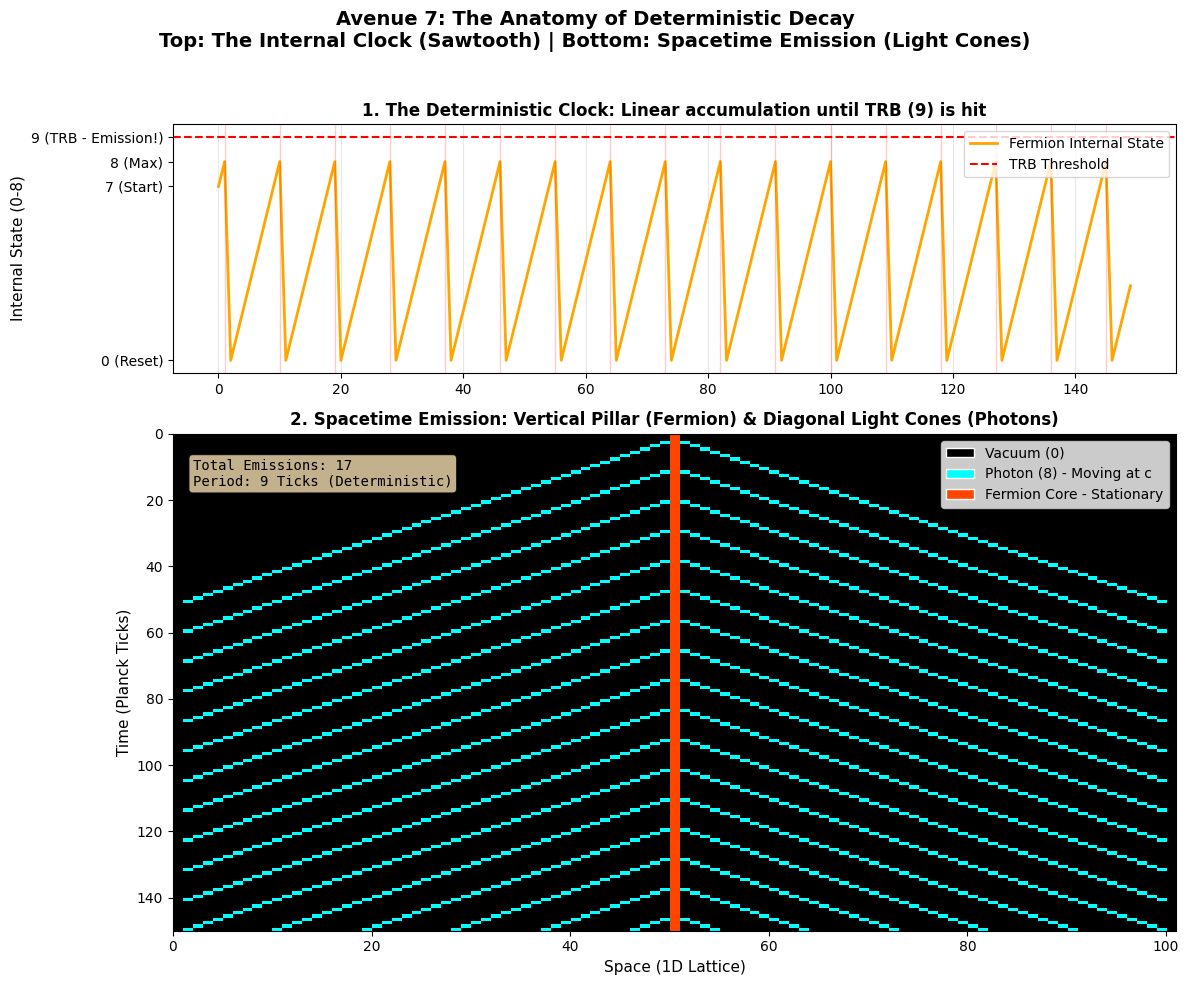

In [1]:
"""
avenue7_test7_part2_expressive_viz_FIXED.py
====================================================================
FIX: Reordered logic to prevent photon erasure & fixed color bounds.
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. RE-RUN SIMULATION (Fixed Logic)
# =============================================================================
T_MAX = 150
GRID_SIZE = 101
CENTER = GRID_SIZE // 2
ALPHABET = 9
TRB = 9

fermion_state = np.zeros(T_MAX)
fermion_grid = np.zeros((T_MAX, GRID_SIZE), dtype=np.int32)
photon_grid = np.zeros((T_MAX, GRID_SIZE), dtype=np.int32)

current_state = 7
fermion_grid[0, CENTER] = 17 # Visual value
fermion_state[0] = current_state

emission_times = []

for t in range(T_MAX - 1):
    # --- STEP 1: PROPAGATE PHOTONS FIRST (Move existing photons) ---
    # Clear next frame for photons
    photon_grid[t+1] = 0

    # Shift left-moving photons (from right to left)
    # We copy from index i+1 to index i
    if t > 0:
        photon_grid[t+1, 1:CENTER] = photon_grid[t, 2:CENTER+1]
        photon_grid[t+1, CENTER+1:-1] = photon_grid[t, CENTER:-2]
    else:
        # Handle t=0 to t=1 shift carefully if needed, usually empty
        pass

    # --- STEP 2: UPDATE FERMION ---
    fermion_grid[t+1] = fermion_grid[t].copy() # Keep stationary
    next_state = current_state + 1

    # --- STEP 3: EMIT NEW PHOTONS (Into the already propagated grid) ---
    if next_state >= TRB:
        emission_times.append(t)
        # Emit into neighbors
        if CENTER - 1 > 0:
            photon_grid[t+1, CENTER - 1] = 8
        if CENTER + 1 < GRID_SIZE - 1:
            photon_grid[t+1, CENTER + 1] = 8

        # Reset Fermion
        current_state = next_state % ALPHABET
    else:
        current_state = next_state

    # Update visual grid for Fermion (Solid Orange)
    # We use a constant high value (e.g., 17) so it doesn't stripe
    fermion_grid[t+1, CENTER] = 17
    fermion_state[t+1] = current_state

# =============================================================================
# 2. VISUALIZATION (Fixed Colors)
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 2]})
fig.suptitle("Avenue 7: The Anatomy of Deterministic Decay\nTop: The Internal Clock (Sawtooth) | Bottom: Spacetime Emission (Light Cones)",
             fontsize=14, fontweight='bold', y=0.98)

# --- TOP PANEL: THE CLOCK ---
time_steps = np.arange(T_MAX)
ax1.plot(time_steps, fermion_state, color='orange', linewidth=2, label='Fermion Internal State')
ax1.set_ylabel('Internal State (0-8)', fontsize=11)
ax1.set_title('1. The Deterministic Clock: Linear accumulation until TRB (9) is hit', fontsize=12, fontweight='bold')
ax1.set_ylim(-0.5, 9.5)
ax1.set_yticks([0, 7, 8, 9])
ax1.set_yticklabels(['0 (Reset)', '7 (Start)', '8 (Max)', '9 (TRB - Emission!)'])
ax1.grid(True, axis='x', alpha=0.3)
ax1.axhline(y=9, color='red', linestyle='--', linewidth=1.5, label='TRB Threshold')
ax1.legend(loc='upper right')

for t_emit in emission_times:
    ax1.axvline(x=t_emit, color='red', alpha=0.2, linewidth=1)

# --- BOTTOM PANEL: SPACETIME DIAGRAM ---
combined_viz = np.zeros((T_MAX, GRID_SIZE))
combined_viz[photon_grid > 0] = 8       # Photon value
combined_viz[fermion_grid > 0] = 17     # Fermion value

# Fixed Colormap: Black (Vacuum), Cyan (Photon), Orange (Fermion)
cmap = colors.ListedColormap(['#000000', '#00FFFF', '#FF4500'])
# Bounds: 0-7 (Black), 8 (Cyan), 9+ (Orange)
bounds = [-0.5, 7.5, 8.5, 25.5]
norm = colors.BoundaryNorm(bounds, cmap.N)

im = ax2.imshow(combined_viz, cmap=cmap, norm=norm, aspect='auto', extent=[0, GRID_SIZE, T_MAX, 0])

ax2.set_ylabel('Time (Planck Ticks)', fontsize=11)
ax2.set_xlabel('Space (1D Lattice)', fontsize=11)
ax2.set_title('2. Spacetime Emission: Vertical Pillar (Fermion) & Diagonal Light Cones (Photons)', fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#000000', edgecolor='white', label='Vacuum (0)'),
    Patch(facecolor='#00FFFF', edgecolor='white', label='Photon (8) - Moving at c'),
    Patch(facecolor='#FF4500', edgecolor='white', label='Fermion Core - Stationary')
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)

textstr = f"Total Emissions: {len(emission_times)}\nPeriod: 9 Ticks (Deterministic)"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax2.text(0.02, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()